# Chronos ile Sentetik EURUSD Mum Üretimi (Close Tahmini + OHLC Giydirme)

Bu notebook:
- CSV'den OHLCV verisini okur
- Amazon Chronos (T5) pipeline'ını yükler
- Sadece **Close** tahmini üretir
- Close'tan **Open/High/Low/Volume** değerlerini kurallı ve stokastik şekilde türetir
- Sonucu grafikte gösterir ve CSV indirir

## Hücre 1: Kurulum
Runtime > Change runtime type > GPU seç. (A100 varsa otomatik hızlanır.)

In [ ]:
# @title 1. Kütüphane Kurulumu
!pip -q install git+https://github.com/amazon-science/chronos-forecasting.git
!pip -q install torch pandas numpy matplotlib mplfinance tqdm

import pandas as pd
import numpy as np
import torch
from chronos import ChronosPipeline
import mplfinance as mpf
import matplotlib.pyplot as plt
import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device.upper()}")
if device == "cpu":
    print("Warning: GPU not found. Runtime > Change runtime type > GPU seç.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.4 MB/s eta 0:00:00
Device: CUDA


## Hücre 2: Veri Yükleme (Sizin Formatınıza Özel)

Beklenen format:
- İlk sütun: datetime (index)
- Sütunlar: open, high, low, close, volume (küçük/büyük fark etmez)

In [ ]:
# @title 2. Veri Setini Yükleme
file_path = "data.csv"  # Colab dosya paneline yüklediğin dosya adı

try:
    df = pd.read_csv(file_path, index_col=0, parse_dates=True)
    df.columns = df.columns.str.strip().str.lower()

    needed = ["open","high","low","close"]
    for c in needed:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")

    if "volume" not in df.columns:
        df["volume"] = 0

    df = df.sort_index()
    print("Loaded.")
    print("Rows:", len(df))
    print(df[["open","high","low","close","volume"]].tail())

    historical_close = df["close"].astype(float)

except FileNotFoundError:
    print("Error: data.csv not found. Creating dummy data for test run.")
    dates = pd.date_range(start="2023-01-01", periods=1000, freq="h")
    df = pd.DataFrame({
        "open": np.random.rand(1000) + 1.0,
        "close": np.random.rand(1000) + 1.0,
        "high": np.random.rand(1000) + 1.1,
        "low":  np.random.rand(1000) + 0.9,
        "volume": np.random.randint(100, 1000, 1000)
    }, index=dates)
    historical_close = df["close"].astype(float)

Loaded.
Rows: 99904
                        open     high      low    close  volume
2025-12-11 14:00:00  1.17134  1.17195  1.17096  1.17166  2406.0
2025-12-11 15:00:00  1.17170  1.17365  1.17133  1.17314  4148.0
2025-12-11 16:00:00  1.17313  1.17487  1.17301  1.17374  4131.0
2025-12-11 17:00:00  1.17375  1.17575  1.17320  1.17560  3779.0
2025-12-11 18:00:00  1.17561  1.17597  1.17462  1.17548  2873.0


## Hücre 3: Chronos Modelini Yükleme

GPU varsa `amazon/chronos-t5-large`, yoksa `amazon/chronos-t5-small`.

In [ ]:
# @title 3. Amazon Chronos Modelini Yükle
model_size = "amazon/chronos-t5-large" if device == "cuda" else "amazon/chronos-t5-small"
print("Loading model:", model_size)

pipeline = ChronosPipeline.from_pretrained(
    model_size,
    device_map=device,
    torch_dtype=torch.bfloat16 if device == "cuda" else torch.float32,
)

print("Model ready.")

Loading model: amazon/chronos-t5-large


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.84G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Model ready.


## Hücre 4: Sentetik Mum Üretim Motoru (Close trend + OHLC giydirme)

Notlar:
- Chronos, `context_len` kadar geçmişten beslenir
- Üretim `chunk_size` bloklar halinde yapılır (24 saat)
- Wick/fitil için lognormal rastgelelik kullanılır
- Volume, mum gövdesi büyüdükçe artacak şekilde simüle edilir

In [ ]:
# @title 4. Sentetik Veri Üretimi (Trend + Mum Giydirme)

def generate_candles(
    model,
    history_series,
    steps=168,        # kaç saat
    context_len=512,  # modelin baktığı geçmiş
    chunk_size=24,    # her seferde kaç saat üretim
    wick_sigma=0.4,   # lognormal sigma
    volume_base=10000
):
    history_series = history_series.dropna()
    if len(history_series) < max(50, context_len):
        raise ValueError(f"Not enough history. Need at least {context_len} close values.")

    print(f"Generating {steps} candles...")

    # Düzeltme: context_tensor CPU'da kalmalı çünkü modelin tokenizer sınırları CPU'da.
    # Model inference sırasında veriyi GPU'ya kendisi alacaktır.
    context_tensor = torch.tensor(history_series.values[-context_len:], device="cpu")

    generated = []
    last_close = float(history_series.iloc[-1])

    base_volatility = history_series.pct_change().dropna().tail(500).std()
    base_volatility = float(base_volatility) if np.isfinite(base_volatility) and base_volatility > 0 else 0.001

    for _ in tqdm.tqdm(range(0, steps, chunk_size)):
        pred_len = min(chunk_size, steps - len(generated))

        forecast = model.predict(
            context_tensor,
            prediction_length=pred_len,
            num_samples=1
        )

        predicted_closes = forecast[0].mean(dim=0).detach().cpu().numpy()

        for close_val in predicted_closes:
            close_val = float(close_val)

            open_val = last_close
            body_max = max(open_val, close_val)
            body_min = min(open_val, close_val)

            current_vol = open_val * base_volatility * np.random.lognormal(mean=0.0, sigma=wick_sigma)
            high_val = body_max + (current_vol * np.random.rand())
            low_val  = body_min - (current_vol * np.random.rand())

            # enforce OHLC sanity
            high_val = max(high_val, body_max)
            low_val  = min(low_val, body_min)

            price_change_pct = abs((close_val - open_val) / open_val) if open_val != 0 else 0.0
            volume = int(volume_base * (1 + (price_change_pct * 100)) * np.random.uniform(0.8, 1.2))

            generated.append({
                "open": open_val,
                "high": high_val,
                "low": low_val,
                "close": close_val,
                "volume": volume
            })

            last_close = close_val

        # sliding window context update
        # Düzeltme: Yeni eklenen veriyi de CPU tensor olarak ekliyoruz.
        new_tensor = torch.tensor(predicted_closes, device="cpu")
        context_tensor = torch.cat((context_tensor, new_tensor))
        if len(context_tensor) > context_len:
            context_tensor = context_tensor[-context_len:]

    syn_df = pd.DataFrame(generated)

    last_date = history_series.index[-1]
    future_dates = pd.date_range(start=last_date, periods=len(syn_df)+1, freq="h")[1:]
    syn_df.index = future_dates
    syn_df.index.name = "datetime"

    return syn_df

# Steps parametresi 5000 olarak güncellendi
synthetic_df = generate_candles(pipeline, historical_close, steps=5000, context_len=512)
print("Done.")
print(synthetic_df.head())

Generating 5000 candles...


100%|██████████| 209/209 [03:17<00:00,  1.06it/s]

Done.
                         open      high       low     close  volume
datetime                                                           
2025-12-11 19:00:00  1.175480  1.175914  1.173106  1.173923   10119
2025-12-11 20:00:00  1.173923  1.173968  1.173684  1.173923    9709
2025-12-11 21:00:00  1.173923  1.173933  1.173613  1.173923   11235
2025-12-11 22:00:00  1.173923  1.174618  1.173046  1.173923   11106
2025-12-11 23:00:00  1.173923  1.174486  1.173511  1.173923    9470


## Hücre 5: Görselleştirme (mplfinance)

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


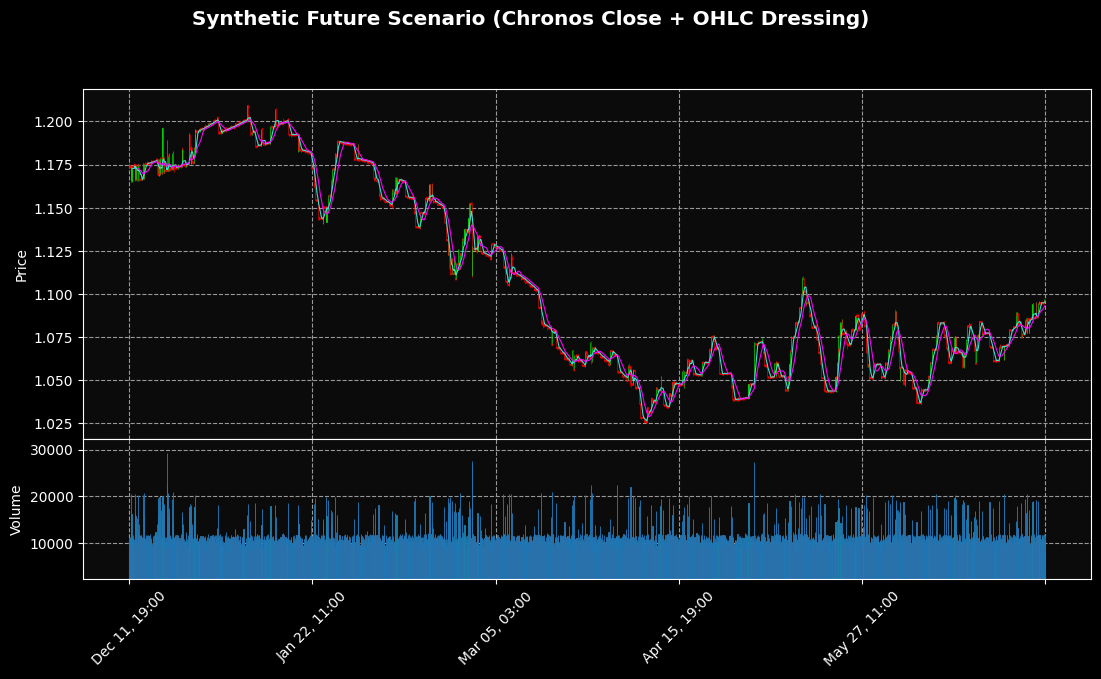

In [ ]:
# @title 5. Sonuçları Görselleştir (Grafik)
plot_df = synthetic_df.copy()
plot_df.columns = ["Open","High","Low","Close","Volume"]

mc = mpf.make_marketcolors(up="#00ff00", down="#ff0000", inherit=True)

# Düzeltme: 'style' parametresi yerine 'base_mpf_style' kullanılmalı
s = mpf.make_mpf_style(marketcolors=mc, base_mpf_style="nightclouds")

mpf.plot(
    plot_df,
    type="candle",
    style=s,
    title="Synthetic Future Scenario (Chronos Close + OHLC Dressing)",
    ylabel="Price",
    volume=True,
    figsize=(14, 7),
    mav=(20, 50)
)

## Hücre 6: Kaydet ve indir

In [ ]:
# @title 6. Veriyi Kaydet ve İndir
from google.colab import files

filename = "sentetik_gelecek_verisi.csv"
synthetic_df.to_csv(filename)
files.download(filename)
print("Downloading:", filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: sentetik_gelecek_verisi.csv
